<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [1]:
# Your code here
!pip install requests beautifulsoup4 pandas matplotlib

Download the webpage at the url


In [ ]:
#your code goes here

Create a soup object


In [ ]:
#your code goes here

Scrape the `Language name` and `annual average salary`.


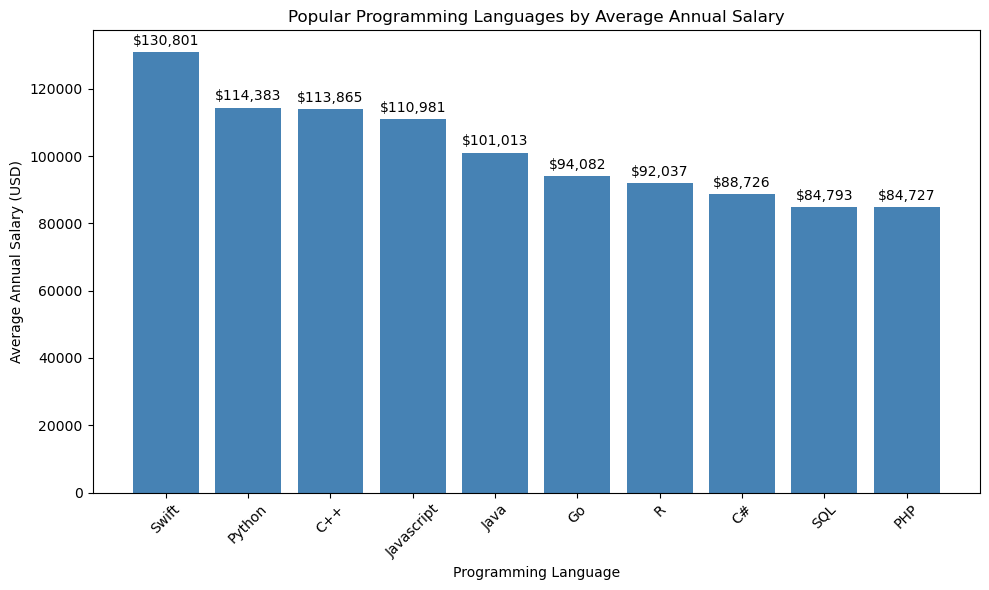

In [2]:
#your code goes here
import requests
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

# 1. Download and parse the page
response = requests.get(url)
response.raise_for_status()
soup = BeautifulSoup(response.text, "html.parser")

# 2. Extract the table rows
table = soup.find("table")
rows = []
for tr in table.find_all("tr")[1:]:            # skip header row
    cols = [td.get_text(strip=True) for td in tr.find_all("td")]
    if cols:
        rows.append(cols)

df = pd.DataFrame(rows, columns=["No.", "Language", "Created By",
                                 "Average Annual Salary", "Learning Difficulty"])

# 3. Clean the salary column ("$114,383" -> 114383)
df["Average Annual Salary"] = (
    df["Average Annual Salary"].str.replace(r"[$,]", "", regex=True).astype(int)
)

# 4. Sort and plot
df = df.sort_values("Average Annual Salary", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(df["Language"], df["Average Annual Salary"], color="steelblue")
plt.bar_label(bars, labels=[f"${v:,}" for v in df["Average Annual Salary"]], padding=3)

plt.title("Popular Programming Languages by Average Annual Salary")
plt.xlabel("Programming Language")
plt.ylabel("Average Annual Salary (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Save the scrapped data into a file named *popular-languages.csv*


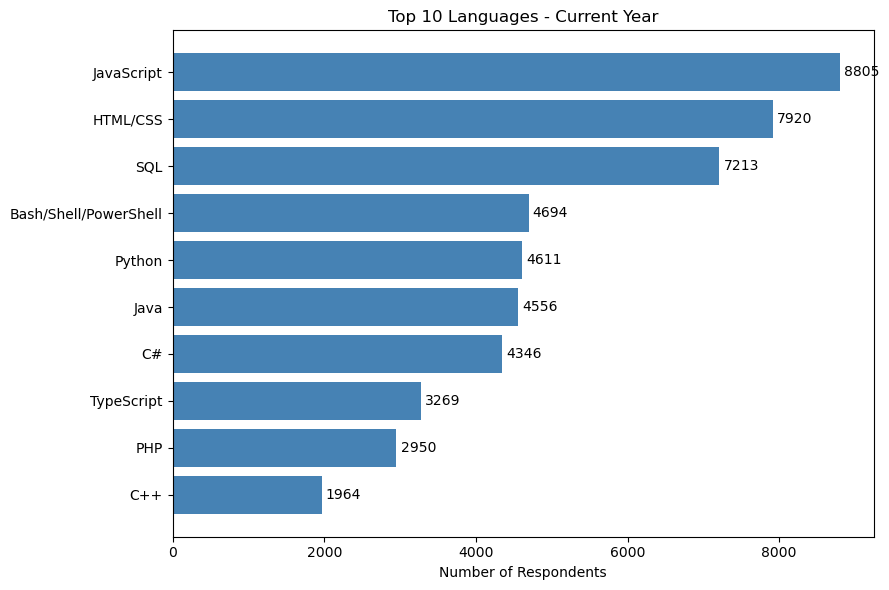

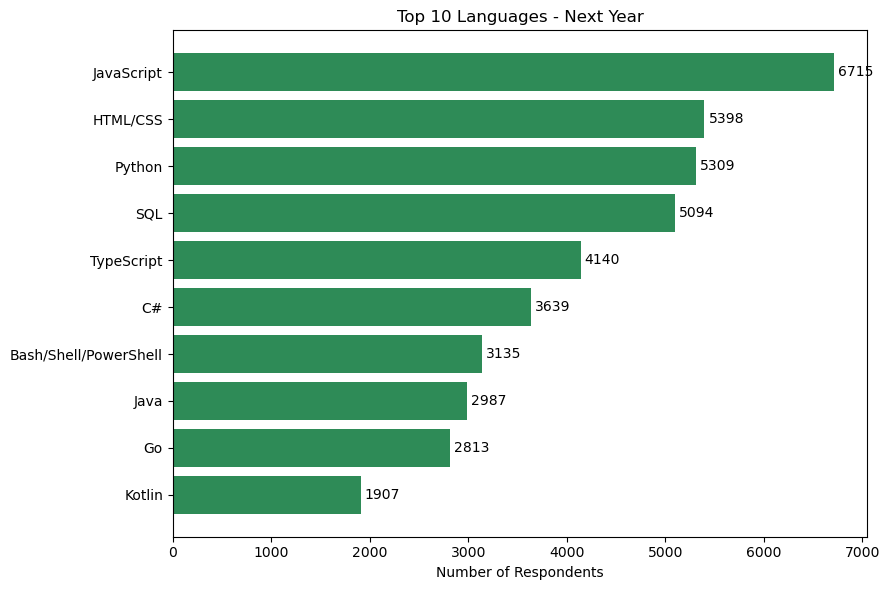

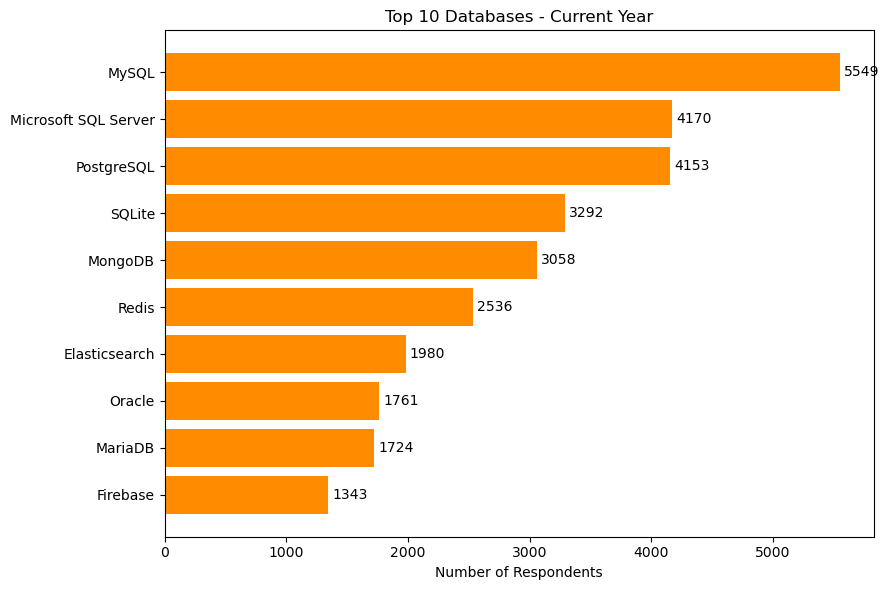

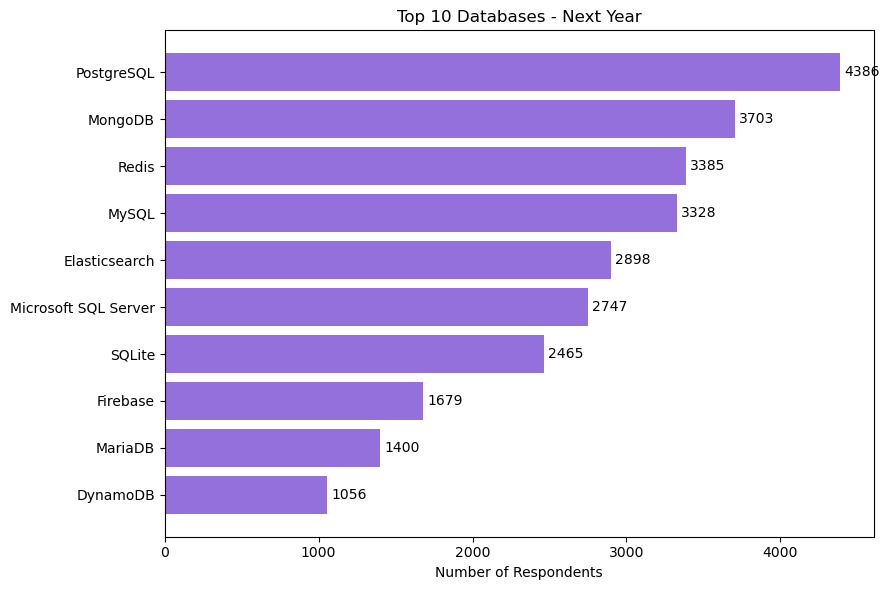

In [3]:
# your code goes here
import pandas as pd
import matplotlib.pyplot as plt

# Survey data (multi-select answers are stored as semicolon-separated text)
url = ("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
       "IBM-DA0321EN-SkillsNetwork/LargeData/m1_survey_data.csv")
df = pd.read_csv(url)

# Column names -> (chart title, color)
COLUMNS = {
    "LanguageWorkedWith":     ("Top 10 Languages - Current Year",   "steelblue"),
    "LanguageDesireNextYear": ("Top 10 Languages - Next Year",      "seagreen"),
    "DatabaseWorkedWith":     ("Top 10 Databases - Current Year",   "darkorange"),
    "DatabaseDesireNextYear": ("Top 10 Databases - Next Year",      "mediumpurple"),
}

def top10(column):
    """Split multi-answer cells on ';', count each item, return the top 10."""
    return (
        df[column]
        .dropna()
        .str.split(";")
        .explode()
        .str.strip()
        .value_counts()
        .head(10)
    )

def plot_top10(column, title, color):
    data = top10(column).sort_values()          # ascending so the largest bar is on top
    plt.figure(figsize=(9, 6))
    bars = plt.barh(data.index, data.values, color=color)
    plt.bar_label(bars, padding=3)
    plt.title(title)
    plt.xlabel("Number of Respondents")
    plt.tight_layout()
    plt.show()

# --- 4 separate graphics ---
for col, (title, color) in COLUMNS.items():
    plot_top10(col, title, color)

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
